# ATML PA6 – Task 2: Grokking & Mechanistic Interpretability

- Modular addition and subtraction tasks with a 1-layer Transformer (TransformerLens).
- Grokking training dynamics (train/test curves).
- Fourier analysis of embeddings and logits.
- Hidden progress measures via restricted / excluded frequency losses.
- Frequency ablations and PCA visualization.
- Modular subtraction variant.
- Approximate Hessian top eigenvalues at different training phases.

## 0. Imports

In [1]:
!pip install transformer_lens

In [2]:
import math
import os
from dataclasses import dataclass
from typing import List, Dict, Tuple

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

import matplotlib.pyplot as plt

from transformer_lens import HookedTransformer, HookedTransformerConfig

# Global config for modular addition / subtraction tasks
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

P = 113  # prime modulus

# Fraction of all (a,b) pairs used for training (rest for test)
TRAIN_FRACTION = 0.3

BATCH_SIZE = 512
# For true grokking behaviour you may need 10k–40k epochs; start smaller for debugging.
NUM_EPOCHS = 15000
EVAL_EVERY = 500  # evaluate and checkpoint every this many epochs

torch.manual_seed(42)

Using device: cuda


In [3]:
import os

OUTPUT_DIR = "task2_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Saving all figures / logs to:", OUTPUT_DIR)

FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
LOG_DIR = os.path.join(OUTPUT_DIR, "logs")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

Saving all figures / logs to: task2_outputs


## 1. Modular Addition

In [4]:
def make_modular_dataset(operation: str = 'add'):
    '''
    Build full dataset of (a,b) pairs for modular addition or subtraction.
    Returns:
      tokens: [N, 3] with format [a, b, '=']
      labels: [N] with c = (a (+|-) b) mod P
    '''
    assert operation in {'add', 'sub'}

    a_vals = []
    b_vals = []
    labels = []

    for a in range(P):
        for b in range(P):
            a_vals.append(a)
            b_vals.append(b)
            if operation == 'add':
                c = (a + b) % P
            else:
                c = (a - b) % P
            labels.append(c)

    a = torch.tensor(a_vals, dtype=torch.long)
    b = torch.tensor(b_vals, dtype=torch.long)
    labels = torch.tensor(labels, dtype=torch.long)

    # '=' token index is P (numbers are 0..P-1)
    eq_token = torch.full_like(a, P, dtype=torch.long)
    tokens = torch.stack([a, b, eq_token], dim=1)  # [N, 3]
    return tokens, labels


def make_dataloaders(operation: str = 'add'):
    tokens, labels = make_modular_dataset(operation)
    dataset = TensorDataset(tokens, labels)

    n_total = len(dataset)
    n_train = int(TRAIN_FRACTION * n_total)
    n_test = n_total - n_train

    train_dataset, test_dataset = random_split(
        dataset,
        [n_train, n_test],
        generator=torch.Generator().manual_seed(0),
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, test_loader

In [5]:
def build_transformer():
    '''
    Build 1-layer decoder-only transformer following the assignment config.
    '''
    cfg = HookedTransformerConfig(
        n_layers=1,
        n_heads=4,
        d_model=128,
        d_head=32,
        d_mlp=512,
        act_fn='relu',
        n_ctx=3,
        d_vocab=P + 1,   # numbers 0..P-1 plus '=' token
        d_vocab_out=P,   # we only predict numbers 0..P-1
        seed=1,
        normalization_type=None,
        init_weights=True,
    )
    model = HookedTransformer(cfg)
    return model


def freeze_biases(model: HookedTransformer):
    '''
    Set all bias parameters to not require grad (kept at zero).
    '''
    for name, param in model.named_parameters():
        if 'bias' in name.lower():
            param.requires_grad_(False)


def cross_entropy_64(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    '''
    Numerically stable cross-entropy in float64 to avoid slingshotting.
    logits: [batch, P]
    targets: [batch]
    '''
    logits64 = logits.to(torch.float64)
    log_probs = torch.log_softmax(logits64, dim=-1)
    loss = nn.functional.nll_loss(log_probs, targets.to(torch.long), reduction='mean')
    return loss.to(logits.dtype)

def save_fig(name: str, subdir: str = None):
    """
    Save current matplotlib figure to OUTPUT_DIR (or subfolder) with given filename.
    Usage:
        plt.plot(...)
        save_fig("addition_train_test_acc.png")
    """
    if subdir is not None:
        dir_path = os.path.join(OUTPUT_DIR, subdir)
        os.makedirs(dir_path, exist_ok=True)
    else:
        dir_path = OUTPUT_DIR

    path = os.path.join(dir_path, name)
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure to:", path)

In [6]:
def get_last_logits(model: HookedTransformer, tokens: torch.Tensor) -> torch.Tensor:
    '''
    Forward pass and return logits at the last position (c position).
    '''
    out = model(tokens)
    # out: [batch, seq_len, d_vocab_out]
    return out[:, -1, :]


@torch.no_grad()
def evaluate_model(model, data_loader, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for tokens, labels in data_loader:
        tokens = tokens.to(device)
        labels = labels.to(device)

        logits = get_last_logits(model, tokens)
        loss = cross_entropy_64(logits, labels)
        total_loss += loss.item() * tokens.size(0)

        preds = logits.argmax(dim=-1)
        total_correct += (preds == labels).sum().item()
        total_count += tokens.size(0)

    avg_loss = total_loss / total_count
    acc = total_correct / total_count
    return avg_loss, acc


def train_modular_task(
    operation: str = 'add',
    num_epochs: int = NUM_EPOCHS,
    eval_every: int = EVAL_EVERY,
    checkpoint_dir: str = 'checkpoints_add',
):
    '''
    Train the 1-layer transformer on modular addition or subtraction.
    Saves checkpoints every eval_every epochs and logs train/test loss and accuracy.
    '''
    os.makedirs(checkpoint_dir, exist_ok=True)

    train_loader, test_loader = make_dataloaders(operation)
    model = build_transformer().to(device)
    freeze_biases(model)

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=1e-3,
        betas=(0.9, 0.98),
        weight_decay=1.0,
    )

    history = {
        'epoch': [],
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }
    checkpoints = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        for tokens, labels in train_loader:
            tokens = tokens.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = get_last_logits(model, tokens)
            loss = cross_entropy_64(logits, labels)
            loss.backward()
            optimizer.step()

        if epoch % eval_every == 0 or epoch == 1 or epoch == num_epochs:
            train_loss, train_acc = evaluate_model(model, train_loader, device)
            test_loss, test_acc = evaluate_model(model, test_loader, device)

            history['epoch'].append(epoch)
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['test_loss'].append(test_loss)
            history['test_acc'].append(test_acc)

            ckpt_path = os.path.join(checkpoint_dir, f'epoch_{epoch}.pt')
            torch.save(model.state_dict(), ckpt_path)
            checkpoints.append({'epoch': epoch, 'path': ckpt_path})

            print(
                f'[{operation}] Epoch {epoch:6d} | '
                f'train loss {train_loss:.4f} acc {train_acc*100:5.1f}% | '
                f'test loss {test_loss:.4f} acc {test_acc*100:5.1f}%'
            )

    return model, history, checkpoints, train_loader, test_loader

In [7]:
# Train modular addition model
add_model, add_history, add_checkpoints, add_train_loader, add_test_loader = train_modular_task(
    operation='add',
    num_epochs=NUM_EPOCHS,
    eval_every=EVAL_EVERY,
    checkpoint_dir='task2_outputs/checkpoints_add',
)

Moving model to device:  cuda
[add] Epoch      1 | train loss 4.7189 acc   1.3% | test loss 4.7373 acc   0.8%
[add] Epoch    500 | train loss 0.0370 acc 100.0% | test loss 12.8840 acc   1.6%
[add] Epoch   1000 | train loss 0.0098 acc 100.0% | test loss 3.9874 acc  26.7%
[add] Epoch   1500 | train loss 0.0000 acc 100.0% | test loss 0.0000 acc 100.0%
[add] Epoch   2000 | train loss 0.0000 acc 100.0% | test loss 0.0000 acc 100.0%
[add] Epoch   2500 | train loss 0.0000 acc 100.0% | test loss 0.0000 acc 100.0%
[add] Epoch   3000 | train loss 0.0000 acc 100.0% | test loss 0.0000 acc 100.0%
[add] Epoch   3500 | train loss 0.0000 acc 100.0% | test loss 0.0000 acc 100.0%
[add] Epoch   4000 | train loss 0.0000 acc 100.0% | test loss 0.0000 acc 100.0%
[add] Epoch   4500 | train loss 0.0000 acc 100.0% | test loss 0.0000 acc 100.0%
[add] Epoch   5000 | train loss 0.0000 acc 100.0% | test loss 0.0000 acc 100.0%
[add] Epoch   5500 | train loss 0.0000 acc 100.0% | test loss 0.0000 acc 100.0%
[add] Epo

In [8]:
import json

with open(os.path.join(LOG_DIR, "add_history.json"), "w") as f:
    json.dump(add_history, f)
print("Saved add_history.json")

Saved add_history.json


In [9]:
def plot_history(history, title_prefix='Addition', tag='add'):
    epochs = history['epoch']

    plt.figure()
    plt.plot(epochs, history['train_acc'], label='Train acc')
    plt.plot(epochs, history['test_acc'], label='Test acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title_prefix}: Train/Test Accuracy')
    plt.legend()
    plt.grid(True)
    save_fig(f'{tag}_train_test_accuracy.png', subdir='figures')
    plt.show()

    plt.figure()
    plt.plot(epochs, history['train_loss'], label='Train loss')
    plt.plot(epochs, history['test_loss'], label='Test loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title_prefix}: Train/Test Loss')
    plt.legend()
    plt.grid(True)
    save_fig(f'{tag}_train_test_loss.png', subdir='figures')
    plt.show()

Saved figure to: task2_outputs/figures/add_train_test_accuracy.png


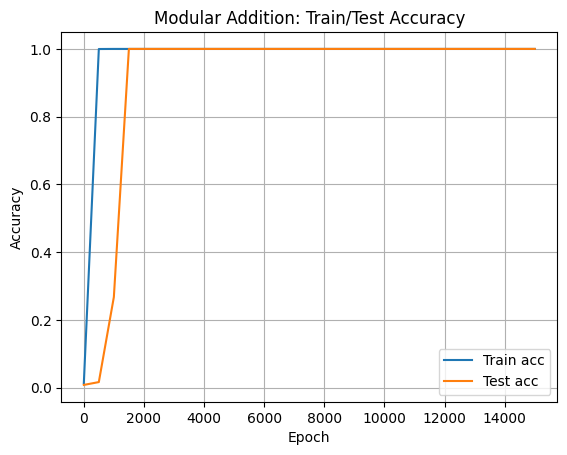

Saved figure to: task2_outputs/figures/add_train_test_loss.png


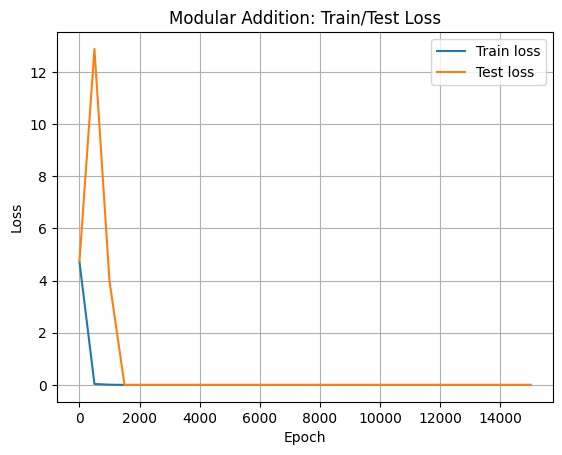

In [10]:
plot_history(add_history, 'Modular Addition', tag='add')

## 2. Reverse Engineering the Fourier Circuit

In [11]:
def get_embedding_matrix(model: HookedTransformer) -> torch.Tensor:
    '''Return embedding matrix W_E of shape [d_vocab, d_model] on CPU.'''
    W_E = model.W_E.detach().cpu()
    return W_E


def fourier_spectrum_embeddings(W_E: torch.Tensor) -> torch.Tensor:
    '''
    Compute L2 norm of Fourier components over vocab dimension.
    Returns amplitude per frequency for number tokens 0..P-1: [P].
    '''
    # Only use number tokens 0..P-1 for Fourier analysis (ignore '=' token)
    W_numbers = W_E[:P]  # [P, d_model]
    W_f = torch.fft.fft(W_numbers, dim=0)  # [P, d_model], complex
    amp = torch.linalg.vector_norm(W_f, dim=-1)  # [P]
    return amp


def plot_fourier_spectrum(amp: torch.Tensor, title='Embedding Fourier spectrum', tag='add_embed'):
    freqs = torch.arange(len(amp))
    plt.figure()
    plt.stem(freqs.numpy(), amp.numpy()) # , use_line_collection=True
    plt.xlabel('Frequency k')
    plt.ylabel('Amplitude (L2 norm)')
    plt.title(title)
    save_fig(f'fourier_spectrum_{tag}.png', subdir='figures')
    plt.show()


def gini_coefficient(x: torch.Tensor) -> float:
    '''Compute Gini coefficient of a non-negative vector x.'''
    x = x.flatten().to(torch.float64)
    if x.numel() == 0:
        return 0.0
    if torch.all(x == 0):
        return 0.0
    x_sorted, _ = torch.sort(x)
    n = x_sorted.numel()
    i = torch.arange(1, n + 1, dtype=torch.float64)
    g = (2 * (i * x_sorted).sum() / (n * x_sorted.sum()) - (n + 1) / n)
    return float(g.item())

Saved figure to: task2_outputs/figures/fourier_spectrum_add_embed.png


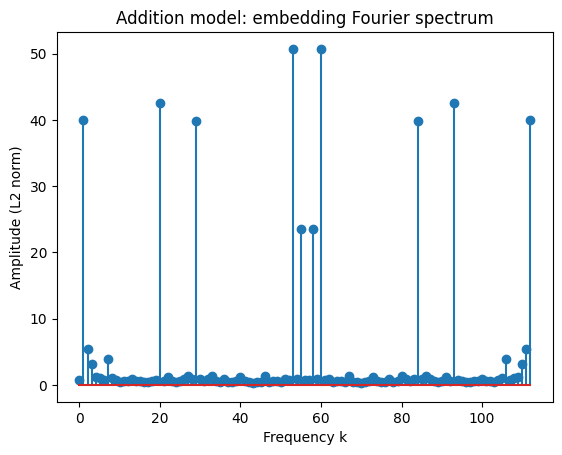

In [12]:
# Embedding Fourier spectrum for addition model
W_E_add = get_embedding_matrix(add_model)
amp_add = fourier_spectrum_embeddings(W_E_add)
plot_fourier_spectrum(amp_add, title='Addition model: embedding Fourier spectrum', tag='add_embed')

### logits by frequency

In [13]:
TOP_K = 4
topk_vals_add, topk_indices_add = torch.topk(amp_add, k=TOP_K)
print('Top frequencies (addition):', topk_indices_add.tolist())
print('Gini coefficient (addition Fourier amps):', gini_coefficient(amp_add))

Top frequencies (addition): [53, 60, 20, 93]
Gini coefficient (addition Fourier amps): 0.7893693490648472


Saved figure to: task2_outputs/figures/full_logits_by_frequency_add.png


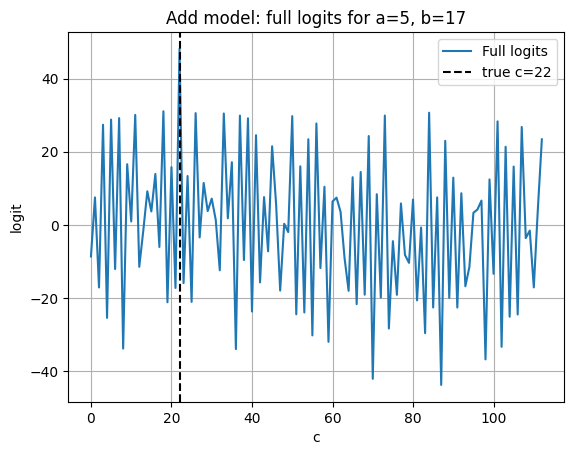

Saved figure to: task2_outputs/figures/logits_by_frequency=53_add_.png


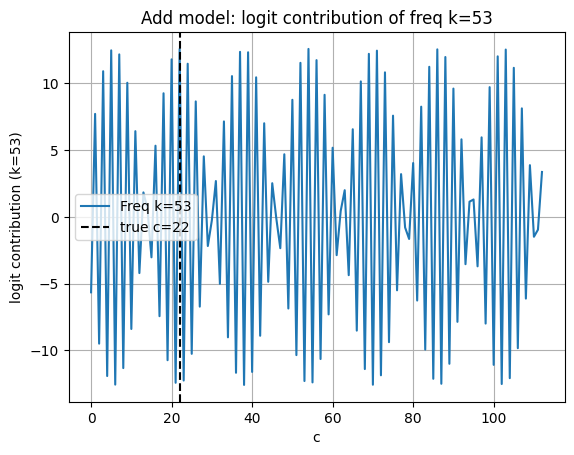

Saved figure to: task2_outputs/figures/logits_by_frequency=60_add_.png


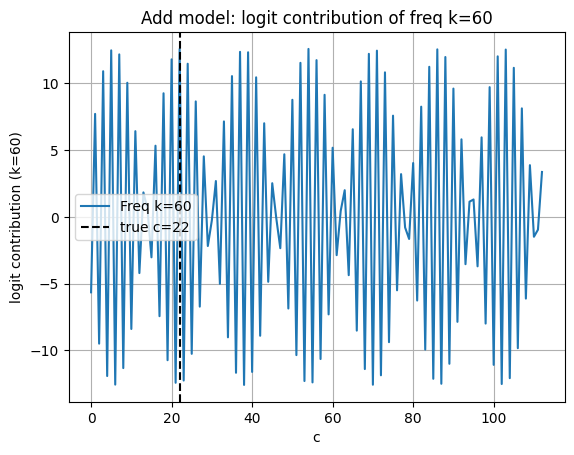

Saved figure to: task2_outputs/figures/logits_by_frequency=20_add_.png


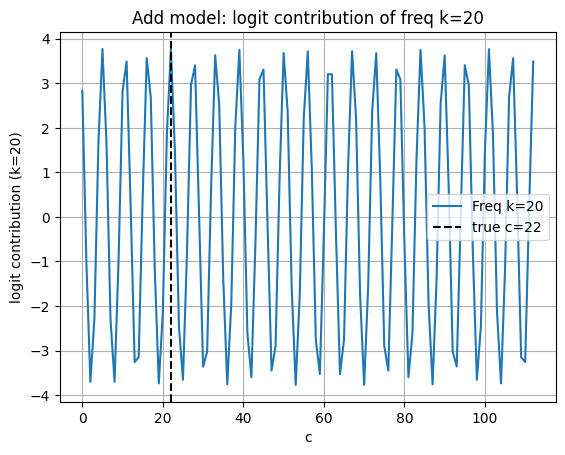

Saved figure to: task2_outputs/figures/logits_by_frequency=93_add_.png


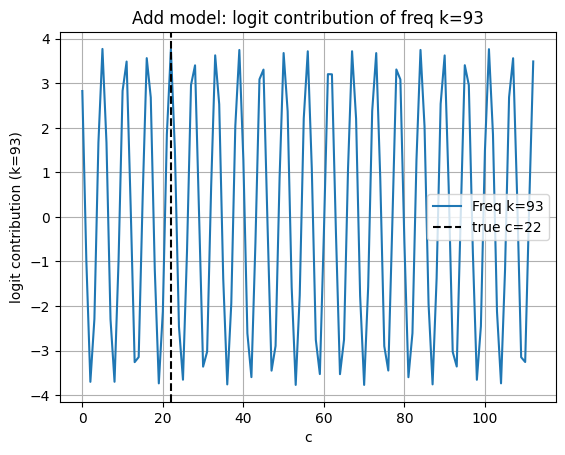

In [14]:
# --- Read-out analysis: logit contributions from key frequencies (Addition) ---

@torch.no_grad()
def plot_logits_by_frequency_for_example(
    model: HookedTransformer,
    a: int,
    b: int,
    key_freqs: torch.Tensor,
    operation: str = 'add',
):
    """
    For a single (a,b), decompose logits into contributions of individual Fourier
    frequencies along the class dimension, and show how they interfere at c.
    """
    model.eval()
    # '=' token is index P
    tokens = torch.tensor([[a, b, P]], dtype=torch.long, device=device)
    logits = get_last_logits(model, tokens).squeeze(0)  # [P]
    c_true = (a + b) % P if operation == 'add' else (a - b) % P

    # Full logits
    c_indices = torch.arange(P)
    plt.figure()
    plt.plot(c_indices.cpu(), logits.detach().cpu().numpy(), label='Full logits')
    plt.axvline(c_true, color='k', linestyle='--', label=f'true c={c_true}')
    plt.xlabel('c')
    plt.ylabel('logit')
    plt.title(f'{operation.capitalize()} model: full logits for a={a}, b={b}')
    plt.legend()
    plt.grid(True)
    save_fig("full_logits_by_frequency_add.png", subdir='figures')
    plt.show()

    # Fourier decomposition
    L = torch.fft.fft(logits, dim=-1)  # [P], complex

    for k in key_freqs:
        k = int(k.item())
        mask = torch.zeros_like(L)
        mask[k] = 1.0
        L_k = L * mask
        logits_k = torch.fft.ifft(L_k, dim=-1).real  # [P]

        plt.figure()
        plt.plot(c_indices.cpu(), logits_k.detach().cpu().numpy(), label=f'Freq k={k}')
        plt.axvline(c_true, color='k', linestyle='--', label=f'true c={c_true}')
        plt.xlabel('c')
        plt.ylabel(f'logit contribution (k={k})')
        plt.title(f'{operation.capitalize()} model: logit contribution of freq k={k}')
        plt.legend()
        plt.grid(True)
        save_fig(f"logits_by_frequency={k}_add_.png", subdir='figures')
        plt.show()


# pick any a,b:
plot_logits_by_frequency_for_example(
    add_model,
    a=5,
    b=17,
    key_freqs=topk_indices_add,
    operation='add',
)

### attention/activation heatmaps

In [47]:
def get_keyfreq_heads_from_trig_corr(
    trig_corr_dict: dict,
    metric: str = 'corr_with_cos_a_plus_b',
):
    """
    For each frequency k, pick the head index with the largest |correlation|
    under the chosen metric.
    For Task 2 (addition), use 'corr_with_cos_a_plus_b'.
    """
    keyfreq_to_head = {}
    for k, res in trig_corr_dict.items():
        vals = torch.tensor(res[metric])  # [n_heads]
        idx = int(torch.argmax(torch.abs(vals)).item())
        keyfreq_to_head[k] = idx
    return keyfreq_to_head


# Task 2: Addition – heads most aligned with cos(w(a+b))
key_heads_add = get_keyfreq_heads_from_trig_corr(add_trig_corr, metric='corr_with_cos_a_plus_b')
print("Key-frequency heads (Addition):", key_heads_add)

Key-frequency heads (Addition): {53: 3, 60: 3, 20: 0, 93: 0}


In [48]:
@torch.no_grad()
def plot_single_head_attention_heatmap(
    model: HookedTransformer,
    operation: str,
    head_idx: int,
    num_examples: int = 2000,
    tag: str = 'add',
):
    """
    Plot average attention pattern for ONE head, which you associate with a key frequency.
    """
    tokens, _ = make_modular_dataset(operation)
    tokens = tokens.to(device)

    if num_examples is not None and num_examples < tokens.size(0):
        idx = torch.randperm(tokens.size(0), device=device)[:num_examples]
        tokens = tokens[idx]

    logits, cache = model.run_with_cache(tokens)
    # pattern: [batch, n_heads, seq, seq]
    attn_pattern = cache['pattern', 0].detach().cpu()
    attn_mean = attn_pattern.mean(dim=0)  # [n_heads, seq, seq]

    head_map = attn_mean[head_idx]  # [seq, seq]

    plt.figure()
    plt.imshow(head_map, aspect='equal')
    plt.colorbar()
    plt.xlabel('Key position')
    plt.ylabel('Query position')
    plt.title(f'{operation.capitalize()} – key-frequency head {head_idx}')
    save_fig(f'attention_heatmap_{tag}_head{head_idx}.png', subdir='figures')
    plt.show()


Addition (Task 2): freq k=53 -> head 3
Saved figure to: task2_outputs/figures/attention_heatmap_add_k53_head3.png


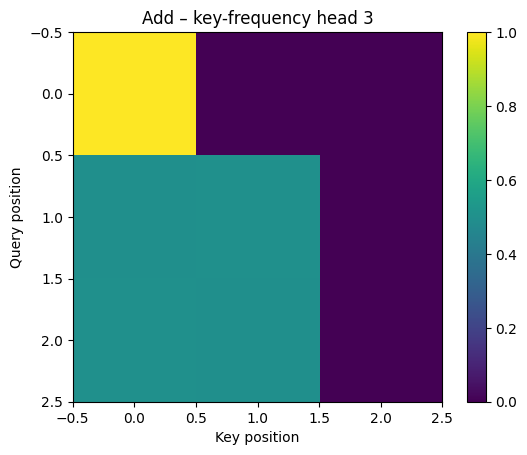

Addition (Task 2): freq k=60 -> head 3
Saved figure to: task2_outputs/figures/attention_heatmap_add_k60_head3.png


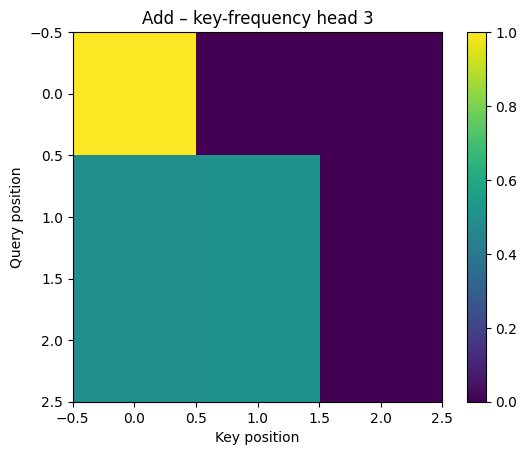

Addition (Task 2): freq k=20 -> head 0
Saved figure to: task2_outputs/figures/attention_heatmap_add_k20_head0.png


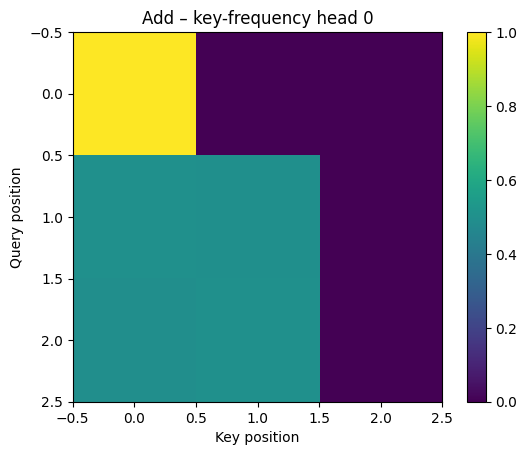

Addition (Task 2): freq k=93 -> head 0
Saved figure to: task2_outputs/figures/attention_heatmap_add_k93_head0.png


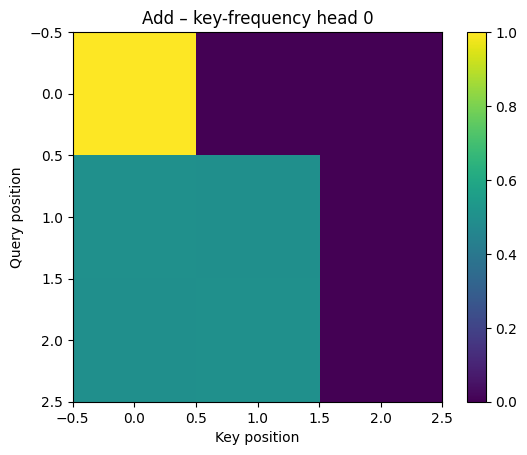

In [49]:
# Task 2: plot attention heatmaps for key-frequency heads (Addition)
for k, h in key_heads_add.items():
    print(f'Addition (Task 2): freq k={k} -> head {h}')
    plot_single_head_attention_heatmap(
        add_model,
        operation='add',
        head_idx=h,
        num_examples=2000,
        tag=f'add_k{k}'
    )
    # You can break after one or two if you don't want all:
    # break


Saved figure to: task2_outputs/figures/attention_heatmap_add.png


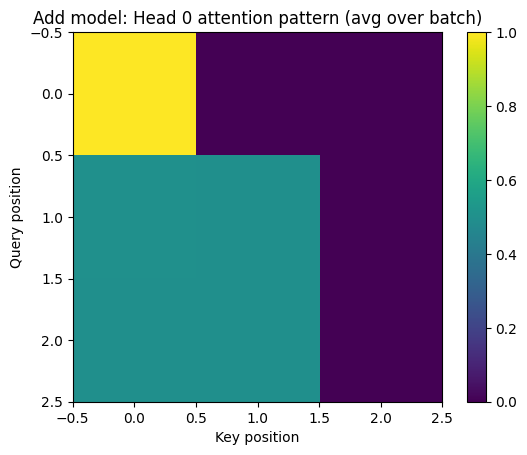

Saved figure to: task2_outputs/figures/attention_heatmap_add.png


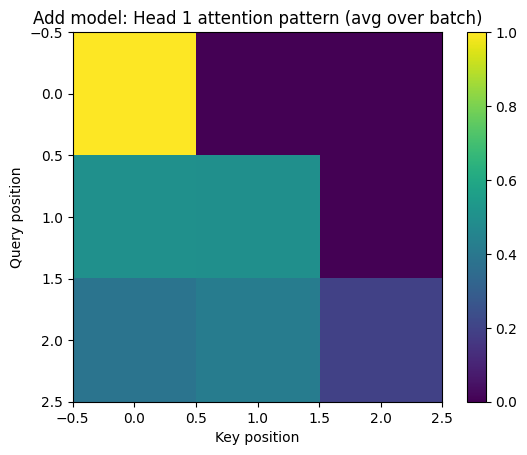

Saved figure to: task2_outputs/figures/attention_heatmap_add.png


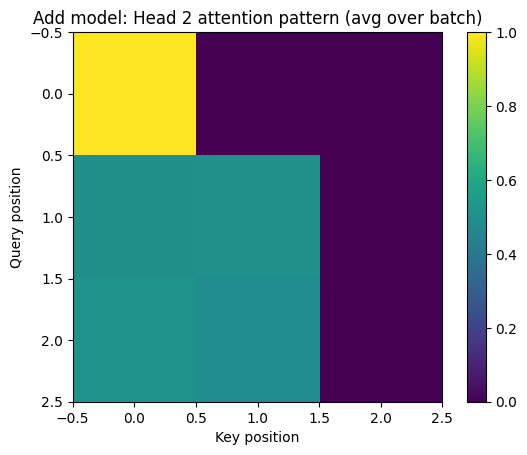

Saved figure to: task2_outputs/figures/attention_heatmap_add.png


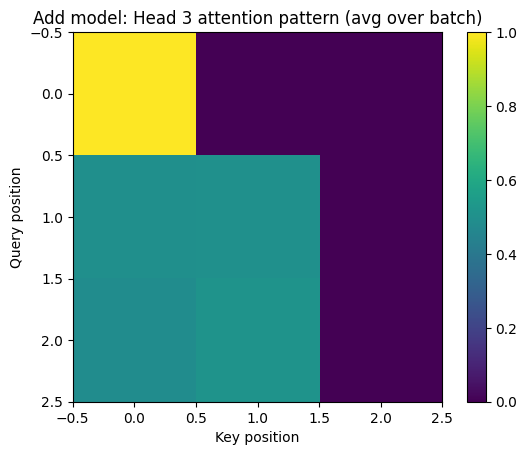

In [15]:
# --- Attention pattern heatmaps (Addition & Subtraction) ---

@torch.no_grad()
def plot_attention_heatmaps(model: HookedTransformer, operation: str = 'add', num_examples: int = 1024):
    """
    Plot average attention pattern for each head (seq x seq) as heatmaps.
    """
    tokens, _ = make_modular_dataset(operation)
    tokens = tokens.to(device)

    if num_examples is not None and num_examples < tokens.size(0):
        idx = torch.randperm(tokens.size(0), device=device)[:num_examples]
        tokens = tokens[idx]

    # _, cache = model.run_with_cache(tokens, return_cache=True)
    logits, cache = model.run_with_cache(tokens)

    # pattern: [batch, n_heads, seq, seq]
    attn_pattern = cache['pattern', 0].detach().cpu()
    attn_mean = attn_pattern.mean(dim=0)  # [n_heads, seq, seq]

    n_heads = attn_mean.shape[0]
    for h in range(n_heads):
        plt.figure()
        plt.imshow(attn_mean[h], aspect='equal')
        plt.colorbar()
        plt.xlabel('Key position')
        plt.ylabel('Query position')
        plt.title(f'{operation.capitalize()} model: Head {h} attention pattern (avg over batch)')
        save_fig(f'attention_heatmap_{operation}.png', subdir='figures')
        plt.show()

# Attention heatmaps for addition models
plot_attention_heatmaps(add_model, operation='add', num_examples=2000)

### mlp heatmaps

In [50]:
@torch.no_grad()
def analyze_mlp_trig_correlations(
    model: HookedTransformer,
    operation: str,
    key_freqs: torch.Tensor,
    num_samples: int = 5000,
):
    """
    For each key frequency k, compute correlation between each MLP neuron at '='
    and the trig feature cos(w(a+b)) (and cos(w(a-b)) for later use).
    Used in:
      - Task 2 (addition): corr_add ~ cos(w(a+b))
      - Task 5 (subtraction): corr_sub ~ cos(w(a-b))
    Returns: {k: {'corr_add': [d_model], 'corr_sub': [d_model]}}
    """
    tokens, _ = make_modular_dataset(operation)
    N = tokens.size(0)
    if num_samples < N:
        idx = torch.randperm(N)[:num_samples]
        tokens = tokens[idx]
    tokens = tokens.to(device)

    a = tokens[:, 0].to(torch.float64)
    b = tokens[:, 1].to(torch.float64)

    logits, cache = model.run_with_cache(tokens)
    # mlp_out: [batch, seq, d_model]
    mlp_out = cache['mlp_out', 0].detach().cpu()
    # '=' position index 2
    neuron_act = mlp_out[:, 2, :]  # [batch, d_model]

    d_model = neuron_act.shape[1]
    results = {}

    for k in key_freqs:
        k_int = int(k.item())
        omega = 2.0 * math.pi * k_int / P

        cos_a = torch.cos(omega * a)
        sin_a = torch.sin(omega * a)
        cos_b = torch.cos(omega * b)
        sin_b = torch.sin(omega * b)

        feature_add = cos_a * cos_b - sin_a * sin_b   # cos(w(a+b))
        feature_sub = cos_a * cos_b + sin_a * sin_b   # cos(w(a-b))

        corr_add = []
        corr_sub = []
        for j in range(d_model):
            act_j = neuron_act[:, j]
            corr_add.append(pearson_corr(act_j, feature_add))
            corr_sub.append(pearson_corr(act_j, feature_sub))

        results[k_int] = {
            'corr_add': corr_add,
            'corr_sub': corr_sub,
        }

    return results


In [52]:
mlp_trig_add = analyze_mlp_trig_correlations(add_model, 'add', topk_indices_add, num_samples=4000)
print("Got MLP trig correlations for addition: ", mlp_trig_add)


Got MLP trig correlations for addition:  {53: {'corr_add': [0.06963535207778668, -0.12741320502373885, -0.3445494038356355, -0.22189942499423682, -0.22415627299772717, -0.36871826234405436, -0.1544635270679375, -0.595513339335708, 0.16197928842829218, -0.742662087054524, 0.8980731587694691, -0.40321381937974576, -0.7300978989584255, -0.3586492370287052, -0.9086612810727851, 0.8554446199055825, -0.0783743625471954, -0.2060585958507277, -0.25774047349654694, -0.2850240432198677, -0.49339704602197443, -0.8423077695898431, 0.2642211066697104, 0.11013956641261746, -0.3607655398743035, 0.6047223182372271, -0.2834600259041245, 0.3784065911252113, 0.10956958053221014, 0.058871637516121296, 0.11390564964788318, 0.10620316418562394, 0.5740449372754317, 0.020844892440974153, -0.16960626230958492, -0.28970927592379386, 0.008308266593199321, 0.061782382576429255, -0.173565691879376, 0.18327262534495029, -0.38497277650540557, -0.8563629674644264, 0.14717189985499832, 0.863458754813937, 0.63444398335

In [53]:
def get_keyfreq_neurons_from_mlp_trig(
    mlp_trig_dict: dict,
    metric: str = 'corr_add',
):
    """
    For each frequency k, pick neuron index with largest |correlation|
    under given metric ('corr_add' or 'corr_sub').
    For Task 2 (addition), use 'corr_add'.
    """
    k_to_neuron = {}
    for k, res in mlp_trig_dict.items():
        vals = torch.tensor(res[metric])  # [d_model]
        idx = int(torch.argmax(torch.abs(vals)).item())
        k_to_neuron[k] = idx
    return k_to_neuron


# Task 2: neurons most aligned with cos(w(a+b))
key_neurons_add = get_keyfreq_neurons_from_mlp_trig(mlp_trig_add, metric='corr_add')
print("Key-frequency neurons (Addition):", key_neurons_add)


Key-frequency neurons (Addition): {53: 97, 60: 97, 20: 74, 93: 74}


Saved figure to: task2_outputs/figures/mlp_activation_grid_add.png


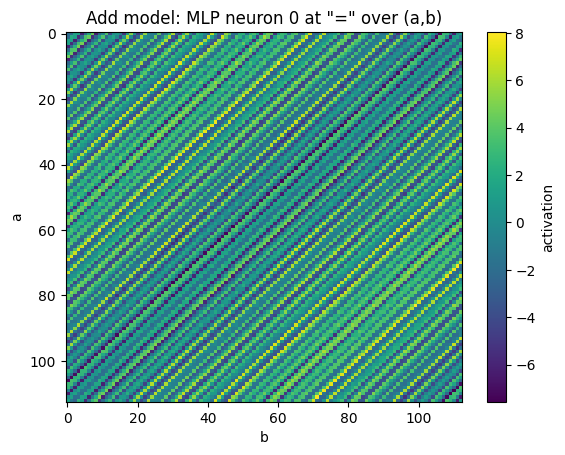

In [16]:
# --- MLP activation heatmaps over (a,b) grid ---

@torch.no_grad()
def plot_mlp_activation_grid(
    model: HookedTransformer,
    operation: str = 'add',
    neuron_idx: int = 0,
):
    """
    For every (a,b), record MLP neuron activation at the '=' position and
    reshape to [P, P] grid, then plot as a heatmap.
    Rows = a, Columns = b.
    """
    tokens, _ = make_modular_dataset(operation)  # [N,3]
    tokens = tokens.to(device)
    # _, cache = model.run_with_cache(tokens, return_cache=True)
    logits, cache = model.run_with_cache(tokens)

    # mlp_out: [batch, seq, d_model]
    mlp_out = cache['mlp_out', 0].detach().cpu()
    # '=' position is index 2
    neuron_act = mlp_out[:, 2, neuron_idx]  # [N]
    grid = neuron_act.view(P, P)  # rows: a, cols: b

    plt.figure()
    plt.imshow(grid, aspect='auto')
    plt.colorbar(label='activation')
    plt.xlabel('b')
    plt.ylabel('a')
    plt.title(f'{operation.capitalize()} model: MLP neuron {neuron_idx} at "=" over (a,b)')
    # save_fig(f'mlp_activation_grid_{operation}.png', subdir='figures')
    plt.show()


# can try different neuron indices to find nice grid patterns
plot_mlp_activation_grid(add_model, operation='add', neuron_idx=0)

Addition (Task 2): freq k=53 -> neuron 97
Saved figure to: task2_outputs/figures/mlp_activation_grid_add.png


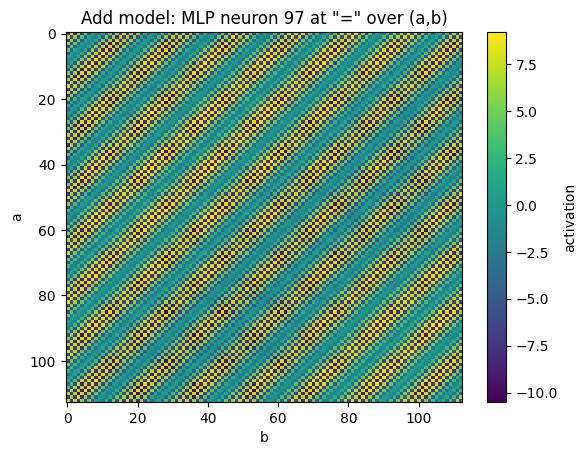

Saved figure to: task2_outputs/figures/mlp_activation_grid_add_k53_neuron97.png
Addition (Task 2): freq k=60 -> neuron 97
Saved figure to: task2_outputs/figures/mlp_activation_grid_add.png


<Figure size 640x480 with 0 Axes>

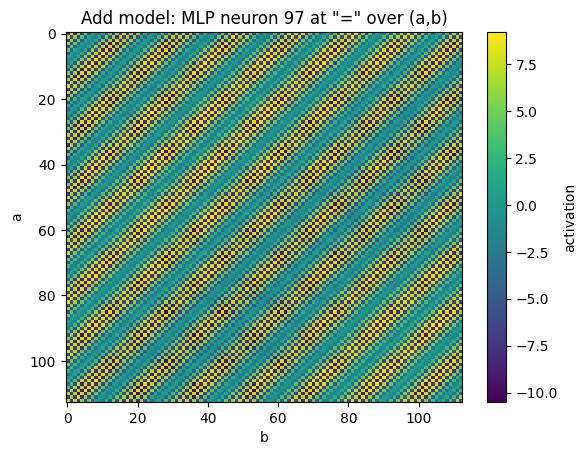

Saved figure to: task2_outputs/figures/mlp_activation_grid_add_k60_neuron97.png
Addition (Task 2): freq k=20 -> neuron 74
Saved figure to: task2_outputs/figures/mlp_activation_grid_add.png


<Figure size 640x480 with 0 Axes>

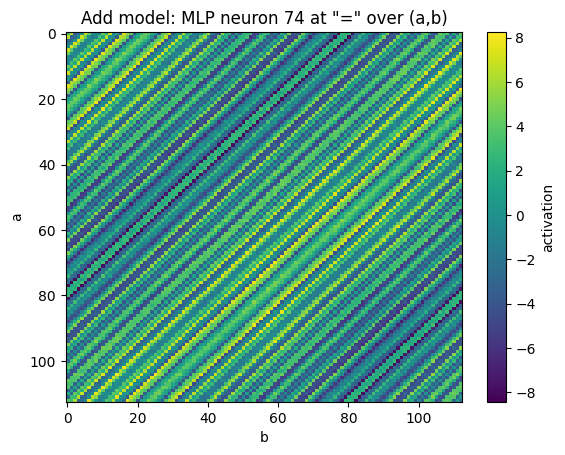

Saved figure to: task2_outputs/figures/mlp_activation_grid_add_k20_neuron74.png
Addition (Task 2): freq k=93 -> neuron 74
Saved figure to: task2_outputs/figures/mlp_activation_grid_add.png


<Figure size 640x480 with 0 Axes>

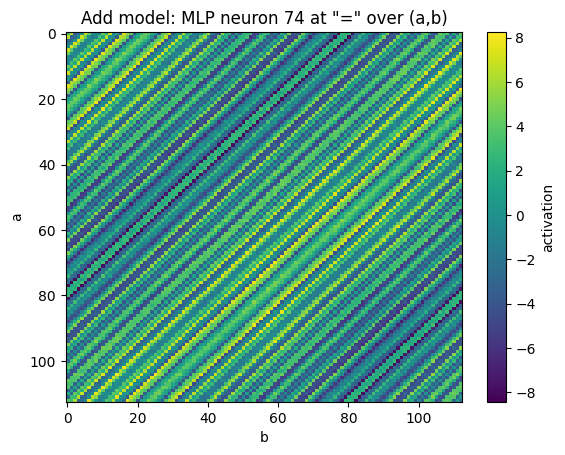

Saved figure to: task2_outputs/figures/mlp_activation_grid_add_k93_neuron74.png


<Figure size 640x480 with 0 Axes>

In [54]:
# Task 2: plot MLP activation grids for key-frequency neurons (Addition)
for k, j in key_neurons_add.items():
    print(f'Addition (Task 2): freq k={k} -> neuron {j}')
    plot_mlp_activation_grid(add_model, operation='add', neuron_idx=j)
    # Optionally use a more specific filename:
    save_fig(f'mlp_activation_grid_add_k{k}_neuron{j}.png', subdir='figures')
    # break  # if you want to limit the number of plots

## 3. Hidden Progress Measures: Restricted and excluded losses

In [17]:
def project_logits_to_frequencies(logits: torch.Tensor, keep_freqs: torch.Tensor) -> torch.Tensor:
    '''
    Project logits onto a subset of Fourier frequencies over the class dimension.
    logits: [batch, P]
    keep_freqs: 1D tensor of frequency indices to keep.
    Returns logits_restricted: [batch, P].
    '''
    L = torch.fft.fft(logits, dim=-1)
    mask = torch.zeros_like(L)
    mask[..., keep_freqs] = 1.0
    L_restricted = L * mask
    logits_restricted = torch.fft.ifft(L_restricted, dim=-1).real
    return logits_restricted


@torch.no_grad()
def compute_restricted_and_excluded_losses(
    model: HookedTransformer,
    checkpoint_path: str,
    train_loader,
    test_loader,
    key_freqs: torch.Tensor,
    device: str,
):
    '''
    For a given checkpoint, compute:
      - Restricted loss on test set: only key frequencies kept.
      - Excluded loss on train set: all non-key frequencies kept.
    '''
    state = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    all_freqs = torch.arange(P)
    key_freqs = key_freqs.to(torch.long)
    keep_mask = torch.zeros(P, dtype=torch.bool)
    keep_mask[key_freqs] = True
    other_freqs = all_freqs[~keep_mask]

    # Restricted loss: test set, only key frequencies
    total_loss_restricted = 0.0
    total_count_test = 0

    for tokens, labels in test_loader:
        tokens = tokens.to(device)
        labels = labels.to(device)
        logits = get_last_logits(model, tokens)
        logits_restricted = project_logits_to_frequencies(logits, key_freqs.to(device))
        loss = cross_entropy_64(logits_restricted, labels)
        total_loss_restricted += loss.item() * tokens.size(0)
        total_count_test += tokens.size(0)

    restricted_test_loss = total_loss_restricted / total_count_test

    # Excluded loss: training set, only non-key frequencies
    total_loss_excluded = 0.0
    total_count_train = 0

    for tokens, labels in train_loader:
        tokens = tokens.to(device)
        labels = labels.to(device)
        logits = get_last_logits(model, tokens)
        logits_excluded = project_logits_to_frequencies(logits, other_freqs.to(device))
        loss = cross_entropy_64(logits_excluded, labels)
        total_loss_excluded += loss.item() * tokens.size(0)
        total_count_train += tokens.size(0)

    excluded_train_loss = total_loss_excluded / total_count_train

    return restricted_test_loss, excluded_train_loss

In [18]:
# Hidden progress measures across checkpoints for addition model
key_freqs_add = topk_indices_add
restricted_losses_add = []
excluded_losses_add = []
checkpoint_epochs_add = []

for ckpt in add_checkpoints:
    epoch = ckpt['epoch']
    path = ckpt['path']
    r_loss, e_loss = compute_restricted_and_excluded_losses(
        add_model, path, add_train_loader, add_test_loader, key_freqs_add, device
    )
    checkpoint_epochs_add.append(epoch)
    restricted_losses_add.append(r_loss)
    excluded_losses_add.append(e_loss)
    print(f'Epoch {epoch}: restricted test loss {r_loss:.4f}, excluded train loss {e_loss:.4f}')

Moving model to device:  cuda
Epoch 1: restricted test loss 4.7276, excluded train loss 4.7192
Moving model to device:  cuda
Epoch 500: restricted test loss 5.3989, excluded train loss 0.3185
Moving model to device:  cuda
Epoch 1000: restricted test loss 3.5656, excluded train loss 0.6787
Moving model to device:  cuda
Epoch 1500: restricted test loss 1.1137, excluded train loss 1.2133
Moving model to device:  cuda
Epoch 2000: restricted test loss 1.1084, excluded train loss 1.2483
Moving model to device:  cuda
Epoch 2500: restricted test loss 1.1061, excluded train loss 1.2570
Moving model to device:  cuda
Epoch 3000: restricted test loss 1.1052, excluded train loss 1.2550
Moving model to device:  cuda
Epoch 3500: restricted test loss 1.1050, excluded train loss 1.2540
Moving model to device:  cuda
Epoch 4000: restricted test loss 1.1049, excluded train loss 1.2489
Moving model to device:  cuda
Epoch 4500: restricted test loss 1.1042, excluded train loss 1.2395
Moving model to device: 

In [19]:
hidden_progress_add = {
    "epochs": checkpoint_epochs_add,
    "restricted_test_loss": restricted_losses_add,
    "excluded_train_loss": excluded_losses_add,
}

torch.save(hidden_progress_add, os.path.join(LOG_DIR, "hidden_progress_add.pt"))
print("Saved hidden_progress_add.pt")

Saved hidden_progress_add.pt


In [46]:
with open(os.path.join(LOG_DIR, "hidden_progess_add.json"), "w") as f:
    json.dump(hidden_progress_add, f)
print("Saved hidden_progress_add.json")

Saved hidden_progress_add.json


Saved figure to: task2_outputs/figures/hidden_progess_measure_add.png


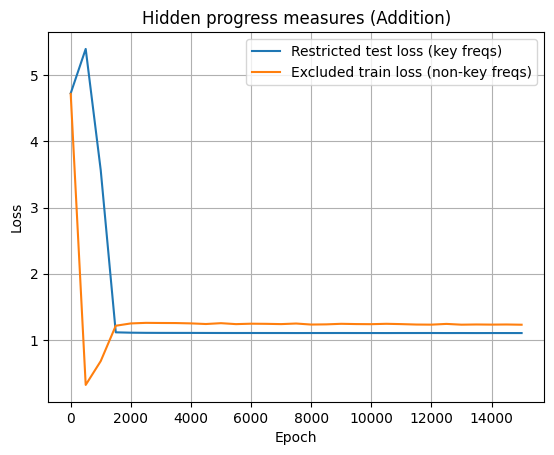

In [20]:
plt.figure()
plt.plot(checkpoint_epochs_add, restricted_losses_add, label='Restricted test loss (key freqs)')
plt.plot(checkpoint_epochs_add, excluded_losses_add, label='Excluded train loss (non-key freqs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Hidden progress measures (Addition)')
plt.legend()
plt.grid(True)
save_fig(f'hidden_progess_measure_add.png', subdir='figures')
plt.show()

## 4. Ablation and Intervention (with PCA)

In [21]:
@torch.no_grad()
def evaluate_with_frequency_mask(model, data_loader, device, key_freqs, mode='zero_key'):
    '''
    Evaluate accuracy under frequency ablations on logits.
    mode:
      - 'zero_key': zero out key frequencies (keep all others)
      - 'keep_only_key': keep only key frequencies, zero out others
    '''
    model.eval()
    key_freqs = key_freqs.to(torch.long)
    all_freqs = torch.arange(P, device=device)
    keep_mask = torch.zeros(P, dtype=torch.bool, device=device)
    keep_mask[key_freqs] = True

    if mode == 'zero_key':
        freqs_to_keep = all_freqs[~keep_mask]
    elif mode == 'keep_only_key':
        freqs_to_keep = all_freqs[keep_mask]
    else:
        raise ValueError("mode must be 'zero_key' or 'keep_only_key'")

    total_correct = 0
    total_count = 0

    for tokens, labels in data_loader:
        tokens = tokens.to(device)
        labels = labels.to(device)

        logits = get_last_logits(model, tokens)
        logits_proj = project_logits_to_frequencies(logits, freqs_to_keep)
        preds = logits_proj.argmax(dim=-1)
        total_correct += (preds == labels).sum().item()
        total_count += tokens.size(0)

    acc = total_correct / total_count
    return acc

In [22]:
# --- Embedding-weight Fourier ablation (Addition model) ---

def ablate_embedding_frequencies_inplace(
    model: HookedTransformer,
    key_freqs: torch.Tensor,
    mode: str = 'zero_key',
):
    """
    In-place Fourier ablation on the embedding matrix W_E along the token dimension (0..P-1).
    mode:
      - 'zero_key': zero out the key frequencies, keep everything else
      - 'keep_only_key': keep only key frequencies, zero out everything else
    """
    with torch.no_grad():
        W_E = model.W_E.detach().cpu().clone()  # [d_vocab, d_model]
        W_numbers = W_E[:P]  # [P, d_model]
        W_f = torch.fft.fft(W_numbers, dim=0)  # [P, d_model]

        mask = torch.ones_like(W_f)
        key_freqs = key_freqs.to(torch.long)
        if mode == 'zero_key':
            mask[key_freqs, :] = 0.0
        elif mode == 'keep_only_key':
            mask[:, :] = 0.0
            mask[key_freqs, :] = 1.0
        else:
            raise ValueError("mode must be 'zero_key' or 'keep_only_key'")

        W_f_new = W_f * mask
        W_numbers_new = torch.fft.ifft(W_f_new, dim=0).real  # [P, d_model]

        W_E_new = W_E.clone()
        W_E_new[:P, :] = W_numbers_new
        W_E_new = W_E_new.to(model.W_E.dtype).to(model.W_E.device)
        model.W_E.data.copy_(W_E_new)


@torch.no_grad()
def evaluate_with_embedding_ablation(
    model: HookedTransformer,
    data_loader,
    key_freqs: torch.Tensor,
    mode: str,
    device: str,
):
    """
    Temporarily ablate W_E in Fourier space, evaluate accuracy, then restore.
    """
    original_W_E = model.W_E.detach().clone()

    ablate_embedding_frequencies_inplace(model, key_freqs, mode=mode)
    loss, acc = evaluate_model(model, data_loader, device)

    # Restore original embeddings
    model.W_E.data.copy_(original_W_E.to(model.W_E.dtype).to(model.W_E.device))
    return loss, acc


In [23]:
# Baseline and ablated accuracies for addition model
baseline_test_loss_add, baseline_test_acc_add = evaluate_model(add_model, add_test_loader, device)
print(f'Baseline test accuracy (no ablation, addition): {baseline_test_acc_add*100:.2f}%')

Baseline test accuracy (no ablation, addition): 100.00%


In [24]:
# Embedding-weight ablations
loss_zero_key, acc_zero_key = evaluate_with_embedding_ablation(
    add_model,
    add_test_loader,
    key_freqs_add,
    mode='zero_key',
    device=device,
)
loss_keep_only, acc_keep_only = evaluate_with_embedding_ablation(
    add_model,
    add_test_loader,
    key_freqs_add,
    mode='keep_only_key',
    device=device,
)

print(f'[Addition] Test acc with key freqs ablated in W_E (zero_key): {acc_zero_key*100:.2f}%')
print(f'[Addition] Test acc with only key freqs kept in W_E: {acc_keep_only*100:.2f}%')

[Addition] Test acc with key freqs ablated in W_E (zero_key): 12.67%
[Addition] Test acc with only key freqs kept in W_E: 17.08%


In [25]:
# acc_zero_key_add = evaluate_with_frequency_mask(add_model, add_test_loader, device, key_freqs_add, mode='zero_key')
# acc_keep_only_key_add = evaluate_with_frequency_mask(add_model, add_test_loader, device, key_freqs_add, mode='keep_only_key')

# print(f'Test accuracy with key freqs zeroed out (addition): {acc_zero_key_add*100:.2f}%')
# print(f'Test accuracy keeping only key freqs (addition): {acc_keep_only_key_add*100:.2f}%')

Saved figure to: task2_outputs/figures/pca_embedding_add.png


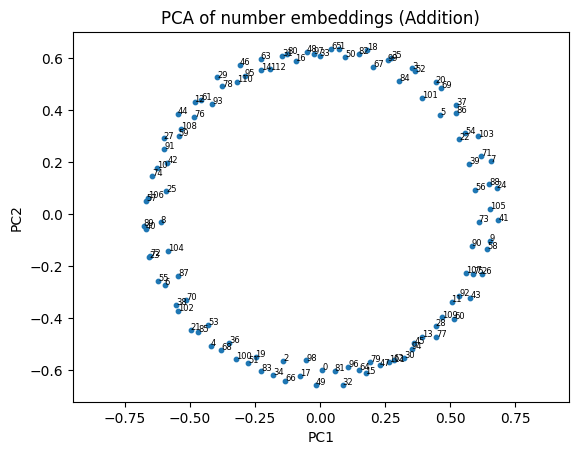

In [26]:
def pca_2d(X: torch.Tensor) -> torch.Tensor:
    '''Simple 2D PCA using SVD. X: [n_samples, d] -> returns [n_samples, 2].'''
    X_centered = X - X.mean(dim=0, keepdim=True)
    # SVD on centered data
    U, S, Vh = torch.linalg.svd(X_centered, full_matrices=False)
    PCs = Vh[:2].T  # [d,2]
    Z = X_centered @ PCs  # [n,2]
    return Z

# # PCA on addition model embeddings (number tokens only), with color coding
# W_numbers_add = W_E_add[:P]
# Z_add = pca_2d(W_numbers_add)  # [P,2]

# plt.figure()
# scatter = plt.scatter(
#     Z_add[:, 0].numpy(),
#     Z_add[:, 1].numpy(),
#     c=torch.arange(P).numpy(),
#     s=20,
#     cmap='hsv',
# )
# plt.colorbar(scatter, label='token value (0..P-1)')
# plt.xlabel('PC1')
# plt.ylabel('PC2')
# plt.title('PCA of number embeddings (Addition) – circular structure')
# plt.axis('equal')
# plt.show()

# PCA on addition model embeddings (number tokens only)
W_numbers_add = W_E_add[:P]
Z_add = pca_2d(W_numbers_add)

plt.figure()
plt.scatter(Z_add[:, 0].numpy(), Z_add[:, 1].numpy(), s=10)
for i in range(P):
    plt.text(Z_add[i, 0].item(), Z_add[i, 1].item(), str(i), fontsize=6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of number embeddings (Addition)')
plt.axis('equal')
save_fig(f'pca_embedding_add.png', subdir='figures')
plt.show()

## 5. Modular Subtraction

In [27]:
# Train modular subtraction model
sub_model, sub_history, sub_checkpoints, sub_train_loader, sub_test_loader = train_modular_task(
    operation='sub',
    num_epochs=NUM_EPOCHS,
    eval_every=EVAL_EVERY,
    checkpoint_dir='task2_outputs/checkpoints_sub',
)

Moving model to device:  cuda
[sub] Epoch      1 | train loss 4.7189 acc   1.2% | test loss 4.7382 acc   0.7%
[sub] Epoch    500 | train loss 0.0758 acc  99.9% | test loss 14.3973 acc   0.1%
[sub] Epoch   1000 | train loss 0.0599 acc  99.9% | test loss 14.3809 acc   0.2%
[sub] Epoch   1500 | train loss 0.0389 acc  99.9% | test loss 13.6007 acc   0.2%
[sub] Epoch   2000 | train loss 0.0273 acc 100.0% | test loss 11.6069 acc   0.3%
[sub] Epoch   2500 | train loss 0.0054 acc 100.0% | test loss 10.6024 acc   1.8%
[sub] Epoch   3000 | train loss 0.0009 acc 100.0% | test loss 0.9626 acc  71.4%
[sub] Epoch   3500 | train loss 0.0000 acc 100.0% | test loss 0.0000 acc 100.0%
[sub] Epoch   4000 | train loss 0.0000 acc 100.0% | test loss 0.0000 acc 100.0%
[sub] Epoch   4500 | train loss 0.0000 acc 100.0% | test loss 0.0000 acc 100.0%
[sub] Epoch   5000 | train loss 0.0000 acc 100.0% | test loss 0.0000 acc 100.0%
[sub] Epoch   5500 | train loss 0.0000 acc 100.0% | test loss 0.0000 acc 100.0%
[sub]

In [28]:
with open(os.path.join(LOG_DIR, "sub_history.json"), "w") as f:
    json.dump(sub_history, f)
print("Saved sub_history.json")


Saved sub_history.json


Saved figure to: task2_outputs/figures/sub_train_test_accuracy.png


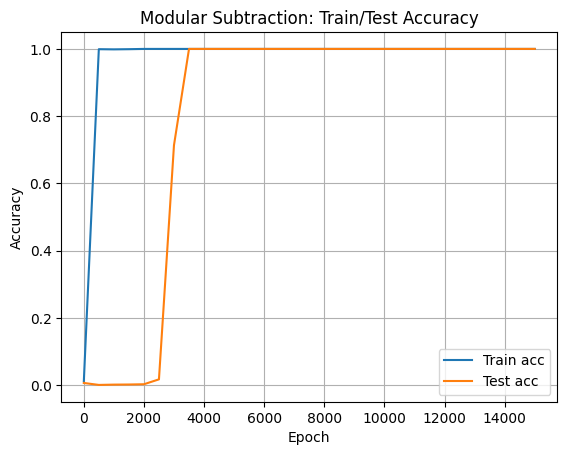

Saved figure to: task2_outputs/figures/sub_train_test_loss.png


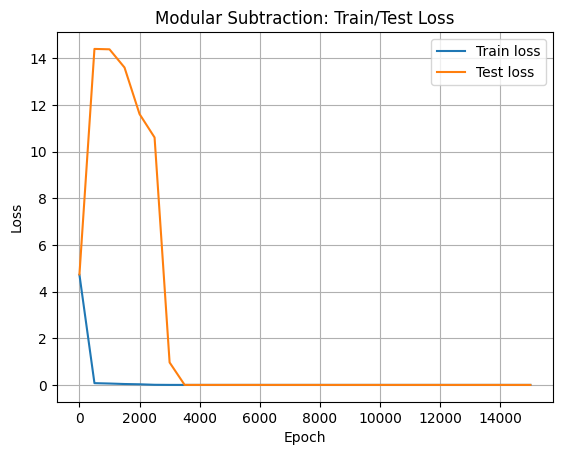

In [29]:
plot_history(sub_history, 'Modular Subtraction', tag='sub')

Saved figure to: task2_outputs/figures/fourier_spectrum_sub_embed.png


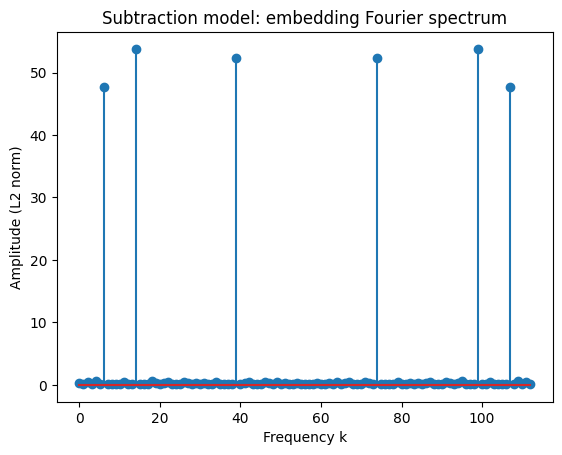

In [30]:
# Fourier spectrum for subtraction model
W_E_sub = get_embedding_matrix(sub_model)
amp_sub = fourier_spectrum_embeddings(W_E_sub)
plot_fourier_spectrum(amp_sub, title='Subtraction model: embedding Fourier spectrum', tag='sub_embed')

In [31]:
TOP_K_SUB = 4
topk_vals_sub, topk_indices_sub = torch.topk(amp_sub, k=TOP_K_SUB)
print('Top frequencies (subtraction):', topk_indices_sub.tolist())
print('Gini coefficient (subtraction Fourier amps):', gini_coefficient(amp_sub))

Top frequencies (subtraction): [14, 99, 39, 74]
Gini coefficient (subtraction Fourier amps): 0.8985155284855559


Saved figure to: task2_outputs/figures/attention_heatmap_sub.png


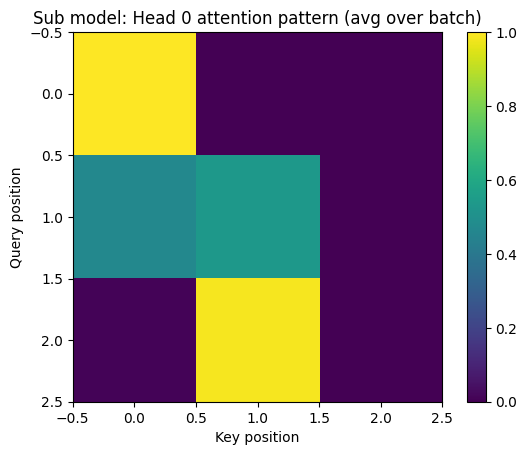

Saved figure to: task2_outputs/figures/attention_heatmap_sub.png


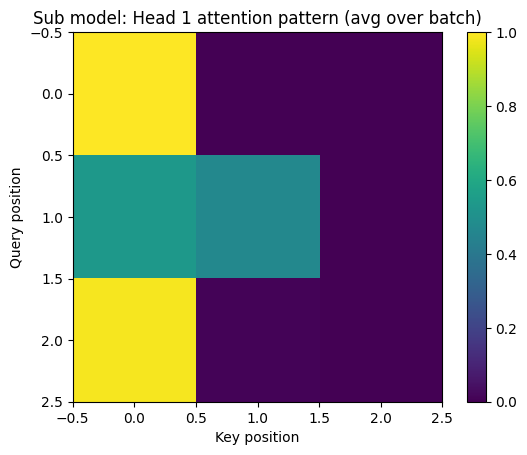

Saved figure to: task2_outputs/figures/attention_heatmap_sub.png


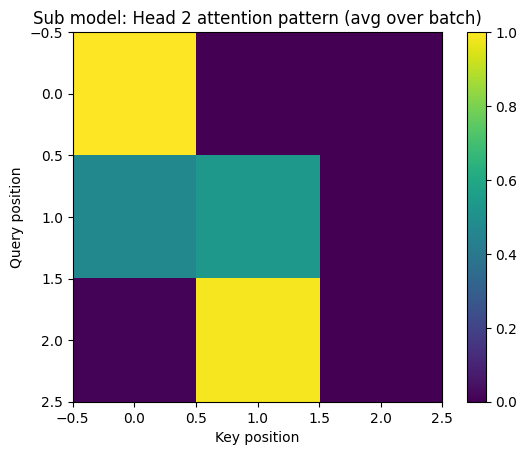

Saved figure to: task2_outputs/figures/attention_heatmap_sub.png


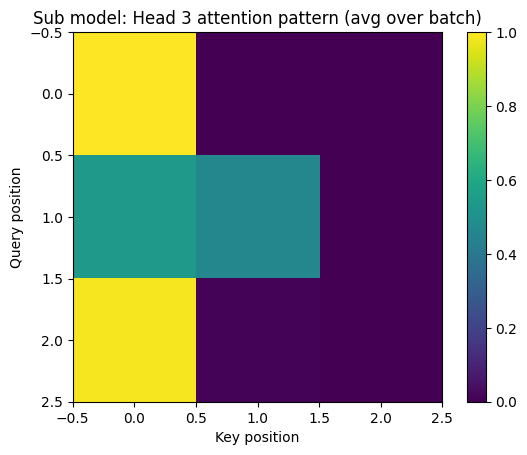

In [32]:
plot_attention_heatmaps(sub_model, operation='sub', num_examples=2000)

Saved figure to: task2_outputs/figures/mlp_activation_grid_sub.png


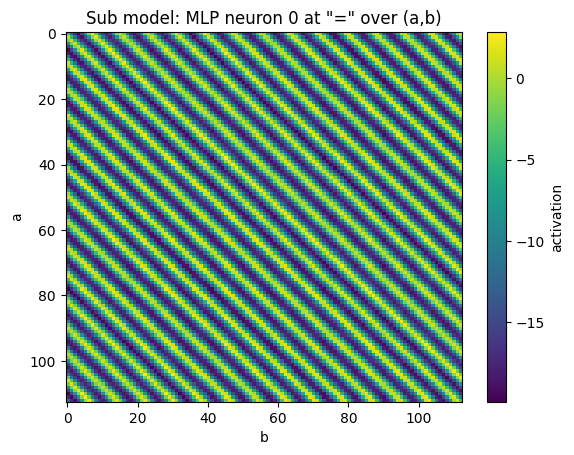

In [33]:
# can try different neuron indices to find nice grid patterns
plot_mlp_activation_grid(sub_model, operation='sub', neuron_idx=0)


In [34]:
# --- Trigonometric correlation analysis for attention heads (Addition & Subtraction) ---

def pearson_corr(x: torch.Tensor, y: torch.Tensor) -> float:
    x = x.detach().to('cpu', torch.float64)
    y = y.detach().to('cpu', torch.float64)
    x = x - x.mean()
    y = y - y.mean()
    denom = (x.std() * y.std() + 1e-8)
    if denom == 0:
        return 0.0
    return float((x * y).mean() / denom)


@torch.no_grad()
def analyze_trig_correlations(
    model: HookedTransformer,
    operation: str,
    key_freqs: torch.Tensor,
    num_samples: int = 5000,
):
    """
    For each key frequency k, compute correlation between attention head outputs (z)
    and:
       cos(w(a+b)) = cos(wa)cos(wb) - sin(wa)sin(wb)
       cos(w(a-b)) = cos(wa)cos(wb) + sin(wa)sin(wb)
    This lets you see whether the model flips the sine sign for subtraction.
    """
    tokens, _ = make_modular_dataset(operation)
    N = tokens.size(0)
    if num_samples < N:
        idx = torch.randperm(N)[:num_samples]
        tokens = tokens[idx]
    tokens = tokens.to(device)

    a = tokens[:, 0].to(torch.float64)
    b = tokens[:, 1].to(torch.float64)

    # _, cache = model.run_with_cache(tokens, return_cache=True)
    logits, cache = model.run_with_cache(tokens)

    # z: [batch, seq, n_heads, d_head] – head outputs before head mixing
    z = cache['z', 0].detach().cpu()
    # Take '=' position (index 2), then average over d_head to get a scalar per head
    z_eq = z[:, 2]  # [batch, n_heads, d_head]
    z_scalar = z_eq.mean(dim=-1)  # [batch, n_heads]

    num_heads = z_scalar.shape[1]
    results = {}

    for k in key_freqs:
        k_int = int(k.item())
        omega = 2.0 * math.pi * k_int / P

        cos_a = torch.cos(omega * a)
        sin_a = torch.sin(omega * a)
        cos_b = torch.cos(omega * b)
        sin_b = torch.sin(omega * b)

        feature_add = cos_a * cos_b - sin_a * sin_b   # cos(w(a+b))
        feature_sub = cos_a * cos_b + sin_a * sin_b   # cos(w(a-b))

        corr_add = []
        corr_sub = []
        for h in range(num_heads):
            head_act = z_scalar[:, h]
            corr_add.append(pearson_corr(head_act, feature_add))
            corr_sub.append(pearson_corr(head_act, feature_sub))

        results[k_int] = {
            'corr_with_cos_a_plus_b': corr_add,
            'corr_with_cos_a_minus_b': corr_sub,
        }

    return results


In [35]:
# Correlations for addition model
add_trig_corr = analyze_trig_correlations(add_model, 'add', topk_indices_add, num_samples=4000)
print('Addition model – trig correlations:')
for k, res in add_trig_corr.items():
    print(f'Freq k={k}:')
    print('  corr with cos(w(a+b)) per head:', res['corr_with_cos_a_plus_b'])
    print('  corr with cos(w(a-b)) per head:', res['corr_with_cos_a_minus_b'])

# Correlations for subtraction model
sub_trig_corr = analyze_trig_correlations(sub_model, 'sub', topk_indices_sub, num_samples=4000)
print('\nSubtraction model – trig correlations:')
for k, res in sub_trig_corr.items():
    print(f'Freq k={k}:')
    print('  corr with cos(w(a+b)) per head:', res['corr_with_cos_a_plus_b'])
    print('  corr with cos(w(a-b)) per head:', res['corr_with_cos_a_minus_b'])

Addition model – trig correlations:
Freq k=53:
  corr with cos(w(a+b)) per head: [0.03179218349736473, 0.008787023302867946, 0.06047695717897924, 0.08380364258218727]
  corr with cos(w(a-b)) per head: [0.02421118768566617, -0.008528821810774887, -0.19093296430250306, -0.10392214033859007]
Freq k=60:
  corr with cos(w(a+b)) per head: [0.03179218349736483, 0.008787023302867627, 0.06047695717896115, 0.08380364258217352]
  corr with cos(w(a-b)) per head: [0.024211187685667025, -0.00852882181077501, -0.19093296430250276, -0.10392214033859039]
Freq k=20:
  corr with cos(w(a+b)) per head: [0.0599114295809314, -0.004214934336194977, -0.016795907258742627, -0.038314821117168475]
  corr with cos(w(a-b)) per head: [-0.10323710023953751, -0.031053656898528133, 0.005260151806373106, 0.02013402864834981]
Freq k=93:
  corr with cos(w(a+b)) per head: [0.059911429580942414, -0.004214934336197281, -0.01679590725874239, -0.03831482111717116]
  corr with cos(w(a-b)) per head: [-0.10323710023953545, -0.031

In [36]:
with open(os.path.join(LOG_DIR, "add_trig_corr.json"), "w") as f:
    json.dump(add_trig_corr, f)
print("Saved add_trig_corr.json")

with open(os.path.join(LOG_DIR, "sub_trig_corr.json"), "w") as f:
    json.dump(sub_trig_corr, f)
print("Saved sub_trig_corr.json")


Saved add_trig_corr.json
Saved sub_trig_corr.json


## 6. Geometry of landscape

In [37]:
def flatten_params(params: List[torch.Tensor]) -> torch.Tensor:
    return torch.cat([p.reshape(-1) for p in params])


def hessian_vector_product(model, params, data_loader, device, v_flat: torch.Tensor) -> torch.Tensor:
    '''Compute Hessian-vector product Hv for a single mini-batch using autograd.'''
    model.zero_grad(set_to_none=True)
    tokens, labels = next(iter(data_loader))
    tokens = tokens.to(device)
    labels = labels.to(device)

    logits = get_last_logits(model, tokens)
    loss = cross_entropy_64(logits, labels)

    grads = torch.autograd.grad(loss, params, create_graph=True)
    flat_grad = flatten_params(grads)
    grad_v = (flat_grad * v_flat).sum()
    Hv = torch.autograd.grad(grad_v, params, retain_graph=False)
    Hv_flat = flatten_params(Hv).detach()
    return Hv_flat


def top_hessian_eigenvalues(
    model,
    data_loader,
    device,
    num_eigs: int = 3,
    num_power_iters: int = 20,
):
    '''
    Approximate top Hessian eigenvalues using power iteration with autograd-based HVP.
    We consider all trainable parameters.
    '''
    params = [p for p in model.parameters() if p.requires_grad]
    n = sum(p.numel() for p in params)

    eigvals = []
    Q = []  # stored approximate eigenvectors for deflation

    for k in range(num_eigs):
        v = torch.randn(n, device=device)
        # Deflate against previous eigenvectors
        for q in Q:
            v = v - (v @ q) * q
        v = v / v.norm()

        for _ in range(num_power_iters):
            Hv = hessian_vector_product(model, params, data_loader, device, v)
            # Deflate again
            for q in Q:
                Hv = Hv - (Hv @ q) * q
            Hv_norm = Hv.norm()
            if Hv_norm.item() == 0:
                break
            v = Hv / Hv_norm

        Hv = hessian_vector_product(model, params, data_loader, device, v)
        lambda_k = (v @ Hv).item()
        eigvals.append(lambda_k)
        Q.append(v / v.norm())

    return eigvals

In [38]:
# Compute Hessian eigenvalues at three checkpoints: early, middle, late (addition model)
indices_add = [0, len(add_checkpoints) // 2, len(add_checkpoints) - 1]
hessian_results_add: Dict[int, List[float]] = {}

for idx in indices_add:
    ckpt = add_checkpoints[idx]
    epoch = ckpt['epoch']
    path = ckpt['path']
    print(f'Computing Hessian eigenvalues at epoch {epoch} (addition model) ...')

    state = torch.load(path, map_location=device)
    add_model.load_state_dict(state)
    add_model.to(device)

    eigvals = top_hessian_eigenvalues(
        add_model,
        add_train_loader,
        device,
        num_eigs=3,
        num_power_iters=15,
    )
    hessian_results_add[epoch] = eigvals
    print(f'Epoch {epoch} top eigenvalues: {eigvals}')

hessian_results_add

Computing Hessian eigenvalues at epoch 1 (addition model) ...
Moving model to device:  cuda
Epoch 1 top eigenvalues: [0.24340090155601501, 0.20305463671684265, 0.16730082035064697]
Computing Hessian eigenvalues at epoch 7500 (addition model) ...
Moving model to device:  cuda
Epoch 7500 top eigenvalues: [0.0003187379625160247, 6.770667096134275e-05, 6.806215969845653e-05]
Computing Hessian eigenvalues at epoch 15000 (addition model) ...
Moving model to device:  cuda
Epoch 15000 top eigenvalues: [0.0003624005476012826, 7.217501115519553e-05, 5.516282908502035e-05]


{1: [0.24340090155601501, 0.20305463671684265, 0.16730082035064697],
 7500: [0.0003187379625160247, 6.770667096134275e-05, 6.806215969845653e-05],
 15000: [0.0003624005476012826, 7.217501115519553e-05, 5.516282908502035e-05]}

In [39]:
with open(os.path.join(LOG_DIR, "hessian_results_add.json"), "w") as f:
    json.dump(hessian_results_add, f)
print("Saved hessian_results_add.json")

Saved hessian_results_add.json


Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Saved figure to: task2_outputs/figures/gini_coefficient_add.png


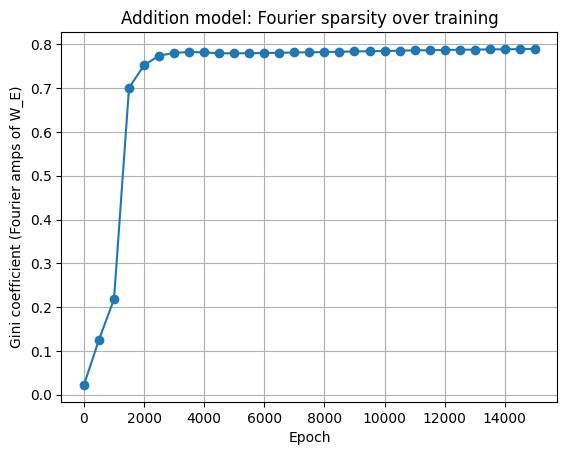

In [40]:
# --- Gini coefficient of Fourier spectrum over training (Addition) ---

gini_over_epochs_add = []
epochs_add = []

for ckpt in add_checkpoints:
    epoch = ckpt['epoch']
    path = ckpt['path']
    state = torch.load(path, map_location=device)
    add_model.load_state_dict(state)
    add_model.to(device)

    W_E_epoch = get_embedding_matrix(add_model)
    amp_epoch = fourier_spectrum_embeddings(W_E_epoch)
    gini_epoch = gini_coefficient(amp_epoch)

    epochs_add.append(epoch)
    gini_over_epochs_add.append(gini_epoch)

plt.figure()
plt.plot(epochs_add, gini_over_epochs_add, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Gini coefficient (Fourier amps of W_E)')
plt.title('Addition model: Fourier sparsity over training')
plt.grid(True)
save_fig(f'gini_coefficient_add.png', subdir='figures')
plt.show()


In [41]:
with open(os.path.join(LOG_DIR, "gini_over_epochs_add.json"), "w") as f:
    json.dump(gini_over_epochs_add, f)
print("Saved gini_over_epochs_add.json")

Saved gini_over_epochs_add.json


In [42]:
torch.save(hessian_results_add, os.path.join(LOG_DIR, "hessian_results_add.pt"))
print("Saved hessian_results_add.pt")

Saved hessian_results_add.pt


In [43]:
print('Hessian top eigenvalues at key epochs (Addition):')
for epoch, eigs in hessian_results_add.items():
    print(f'Epoch {epoch}: eigenvalues = {eigs}')

print('\nGini vs epoch (Addition):')
for e, g in zip(epochs_add, gini_over_epochs_add):
    print(f'Epoch {e}: Gini = {g:.4f}')


Hessian top eigenvalues at key epochs (Addition):
Epoch 1: eigenvalues = [0.24340090155601501, 0.20305463671684265, 0.16730082035064697]
Epoch 7500: eigenvalues = [0.0003187379625160247, 6.770667096134275e-05, 6.806215969845653e-05]
Epoch 15000: eigenvalues = [0.0003624005476012826, 7.217501115519553e-05, 5.516282908502035e-05]

Gini vs epoch (Addition):
Epoch 1: Gini = 0.0225
Epoch 500: Gini = 0.1257
Epoch 1000: Gini = 0.2179
Epoch 1500: Gini = 0.7005
Epoch 2000: Gini = 0.7522
Epoch 2500: Gini = 0.7740
Epoch 3000: Gini = 0.7801
Epoch 3500: Gini = 0.7825
Epoch 4000: Gini = 0.7815
Epoch 4500: Gini = 0.7793
Epoch 5000: Gini = 0.7794
Epoch 5500: Gini = 0.7795
Epoch 6000: Gini = 0.7801
Epoch 6500: Gini = 0.7805
Epoch 7000: Gini = 0.7814
Epoch 7500: Gini = 0.7816
Epoch 8000: Gini = 0.7823
Epoch 8500: Gini = 0.7829
Epoch 9000: Gini = 0.7835
Epoch 9500: Gini = 0.7842
Epoch 10000: Gini = 0.7845
Epoch 10500: Gini = 0.7855
Epoch 11000: Gini = 0.7861
Epoch 11500: Gini = 0.7865
Epoch 12000: Gini =

## zip

In [55]:
import shutil

shutil.make_archive("task2_outputs", "zip", OUTPUT_DIR)
print("Created archive:", "task2_outputs.zip")

Created archive: task2_outputs.zip
